This file creates 2 versions for the ML model training data. 

- ***1st Attempt***: joins the business entries just with the neighborhood data
- ***2nd Attempt***: joins the business entries both with the neighborhood and the municipal community data

## ***Initials***

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

## ***Help Functions***

In [3]:
def return_results_as_dataframe(results, n=3):
    # List to hold rows
    final_results = []

    # Loop through each NACE code and its top-N DataFrame
    for nace_code, df in results.items():
        df_topn = df.reset_index(drop=True)

        # Pad with NaNs if fewer than n rows
        while len(df_topn) < n:
            df_topn.loc[len(df_topn)] = [None] * len(df_topn.columns)

        row = {"NACE_Code": nace_code}

        # Dynamically fill TopN and DistanceN
        for i in range(n):
            row[f"Top{i+1}"] = df_topn.loc[i, "Neighborhood"]
            row[f"Distance{i+1}"] = df_topn.loc[i, "Distance_to_Ideal"]

        final_results.append(row)

    # Create the final DataFrame
    results_df = pd.DataFrame(final_results)
    return results_df


In [4]:
# function that: returns the optimal k
def find_optimal_k(X_scaled, nace_code, approach_name, max_k=10, plot=False):
    n_samples = X_scaled.shape[0]
    effective_max_k = min(max_k, n_samples)

    inertias = []
    for k in range(1, effective_max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)

    if plot:
        plt.plot(range(1, effective_max_k + 1), inertias, 'bo-')
        plt.xlabel('Number of clusters')
        plt.ylabel('Inertia')
        plt.title('Elbow Method For Optimal k' + f' (NACE {nace_code})')
        nace_str = str(nace_code)
        filename = f'C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\6. Ground Truths\\2. Unsupervised Approach\\' + f'{approach_name}' + '\\Extracted Visualizations\\Elbow Method Plots\\' + f'elbow_nace_{nace_str.replace(".", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()

    if effective_max_k == 1:
        return 1

    deltas = [inertias[i] - inertias[i+1] for i in range(len(inertias) - 1)]
    best_k = deltas.index(max(deltas)) + 1
    return best_k

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

def _project_to_2d(X_scaled, method="pca", random_state=42):
    """
    Projects scaled features to 2D for visualization.
    method: "pca" (fast, reproducible) or "tsne" (nonlinear, prettier but slower).
    Returns: Z (n_samples x 2), transformer (PCA or TSNE object) or None for TSNE
    """
    if method.lower() == "pca":
        pca = PCA(n_components=2, random_state=random_state)
        Z = pca.fit_transform(X_scaled)
        return Z, pca
    elif method.lower() in ["tsne", "t-sne"]:
        tsne = TSNE(n_components=2, random_state=random_state, init="pca", learning_rate="auto")
        Z = tsne.fit_transform(X_scaled)
        return Z, None
    else:
        raise ValueError("method must be 'pca' or 'tsne'.")

def _transform_points_to_2d(points_scaled, transformer, base_X_scaled, method="pca", random_state=42):
    """
    Projects *new* scaled points into the same 2D space.
    For PCA we can use transform; for t-SNE we refit jointly to keep a shared space.
    """
    if method.lower() == "pca":
        return transformer.transform(points_scaled)
    else:
        # Refit t-SNE on combined data to get a shared embedding
        combined = np.vstack([base_X_scaled, points_scaled])
        tsne = TSNE(n_components=2, random_state=random_state, init="pca", learning_rate="auto")
        Z_all = tsne.fit_transform(combined)
        return Z_all[-len(points_scaled):]


In [51]:
def visualize_clusters_with_candidates(
    subset,                 # DataFrame of businesses for the NACE (already filtered)
    feature_columns,        # list of numeric features used for clustering
    scaler,                 # fitted StandardScaler() from your function
    kmeans,                 # fitted KMeans
    ideal_cluster_id,       # int
    candidate_locations_df, # DataFrame of candidates
    method="pca",           # "pca" or "tsne"
    title_prefix=""
):
    # Prepare scaled matrices
    X_scaled = scaler.transform(subset[feature_columns])
    Xc_scaled = scaler.transform(candidate_locations_df[feature_columns])

    # 2D projection for businesses
    Z, transformer = _project_to_2d(X_scaled, method=method)
    # Project candidates in the *same* 2D space
    Zc = _transform_points_to_2d(Xc_scaled, transformer, X_scaled, method=method)

    # Compute 2D KMeans centroids by projecting cluster centers
    if method.lower() == "pca":
        centers_2d = transformer.transform(kmeans.cluster_centers_)
    else:
        # For t-SNE we embed centers by the same trick (fit on data + centers)
        centers_2d = _transform_points_to_2d(kmeans.cluster_centers_, transformer=None,
                                             base_X_scaled=X_scaled, method="tsne")

    labels = subset["Cluster"].to_numpy()

    # Plot: clusters
    plt.figure(figsize=(8, 6))
    for c in np.unique(labels):
        mask = labels == c
        plt.scatter(Z[mask, 0], Z[mask, 1], alpha=0.7, s=25)

    # Plot centroids with labels
    for i, (cx, cy) in enumerate(centers_2d):
        if i == ideal_cluster_id:
            plt.scatter(cx, cy, marker="X", s=240, edgecolor="black", linewidth=1.5,
                        label=f"Ideal Centroid (Cluster {i})", c="green")
        else:
            plt.scatter(cx, cy, marker="X", s=160, edgecolor="black", linewidth=1.0,
                        label=f"Centroid {i}", c="yellow")

    # Overlay candidates
    plt.scatter(Zc[:, 0], Zc[:, 1], marker="^", s=60, alpha=0.85, label="Candidates")

    # Optionally draw faint lines from each candidate to the ideal centroid
    cx, cy = centers_2d[ideal_cluster_id]
    for (x, y) in Zc:
        plt.plot([cx, x], [cy, y], linewidth=0.6, alpha=0.4)

    plt.title(f"{title_prefix}Optimal Cluster Centroid & Candidates ({method.upper()})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [41]:
def find_top_n_for_nace_code(
    nace_code, df, candidate_locations_df, feature_columns, top_n, judge_feature, approach_name, optimal_K=False, min_samples=5, plot=False, extra_visuals=False, method="pca"
):

    try:
        # Filter businesses of this NACE code
        subset = df[df['NACE Code'] == nace_code].copy()
        subset = subset.dropna(subset=feature_columns)
        X = subset[feature_columns]

        # Normalize and perform KMeans clustering
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X) 

        if len(subset) >= 2:

            # find the optimal k if specified
            if optimal_K:
                k = find_optimal_k(X_scaled, plot=plot, nace_code=nace_code, approach_name=approach_name)
            else:
                k = 2

            # perform k-means clustering
            kmeans = KMeans(n_clusters=k, random_state=42)
            subset['Cluster'] = kmeans.fit_predict(X_scaled)
            
            # Identify the "ideal" cluster (based on the 'judge_feature')
            if judge_feature == 'Rating':
                if subset[judge_feature].isna().all():
                    judge_feature = 'distance_to_volos_center_km'
                else:
                    subset[judge_feature] = subset[judge_feature].fillna(subset[judge_feature].mean())
                
            # Select the "best" cluster depending on the metric direction
            cluster_means = subset.groupby('Cluster')[judge_feature].mean()
            if judge_feature in ['Rating', 'Reviews']:
                best_cluster_id = cluster_means.idxmax()
            else:
                best_cluster_id = cluster_means.idxmin()

            ideal_centroid = kmeans.cluster_centers_[best_cluster_id]
        else:
            ideal_centroid = X_scaled[0]


        if extra_visuals:
            
            # Visualize:
            ideal_cluster_id = best_cluster_id

            # Visualize the clustering + candidates
            subset['Cluster'] = kmeans.labels_
            visualize_clusters_with_candidates(
                subset=subset,
                feature_columns=feature_columns,
                scaler=scaler,
                kmeans=kmeans,
                ideal_cluster_id=ideal_cluster_id,
                candidate_locations_df=candidate_locations_df,
                method=method,  # try "tsne" for a nonlinear view too
                title_prefix=f"NACE {nace_code} – "
            )



        # Evaluate every candidate
        X_comm = candidate_locations_df[feature_columns]
        X_comm_scaled = scaler.transform(X_comm)
        
        # Compute Euclidean distance to the ideal centroid
        distances = np.linalg.norm(X_comm_scaled - ideal_centroid, axis=1)
        
        # Get top top_n
        candidate_locations_df = candidate_locations_df.copy()
        candidate_locations_df['Distance_to_Ideal'] = distances
        top_communities = candidate_locations_df.sort_values('Distance_to_Ideal')
        
        return top_communities[['Neighborhood', 'Distance_to_Ideal']].head(top_n)
    
    except Exception as e:
        print(f"Error processing NACE {nace_code}: {str(e)}")
        return None

## ***Load Data***

In [8]:
df_business_ELSTAT_neighborhood = pd.read_csv('C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\4. Joining Datasets\\3. Joining - Business - Neighborhood Data\\Extracted CSV Files\\business_data_ELSTAT_neighborhood.csv')

In [9]:
print(df_business_ELSTAT_neighborhood.shape)
print(df_business_ELSTAT_neighborhood.columns)
df_business_ELSTAT_neighborhood.head()

(3882, 42)
Index(['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country',
       'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description',
       'NACE Code', 'NACE Description (EN)', 'Municipal_Community',
       'Neighborhood', 'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ', 'ΔΗΜΟΣ', 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ',
       'Population', 'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct',
       'Διαζευγμένοι_pct', 'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct',
       'low_education_pct', 'medium_education_pct', 'high_education_pct',
       'unemployment_rate', 'labor_force_participation_rate',
       'primary_sector_pct', 'secondary_sector_pct', 'tertiary_sector_pct',
       'Area_km2', 'Neighborhood_Area_km2', 'distance_to_volos_center_km',
       'distance_to_volos_port_km', 'dist_to_main_road_km',
       'dist_to_bus_stop_km', 'dist_to_university_km'],
      dtype='object')


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,...,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2,Neighborhood_Area_km2,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,dist_to_university_km
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.0313,0.1666,0.8022,26.790807,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.0313,0.1666,0.8022,26.790807,4.848904,3.508166,2.529372,0.224486,0.246542,1.913456
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.0313,0.1666,0.8022,26.790807,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.0313,0.1666,0.8022,26.790807,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.0313,0.1666,0.8022,26.790807,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331


In [10]:
municipal_community_columns = ['Population', 'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct',
       'Διαζευγμένοι_pct', 'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct',
       'low_education_pct', 'medium_education_pct', 'high_education_pct',
       'unemployment_rate', 'labor_force_participation_rate',
       'primary_sector_pct', 'secondary_sector_pct', 'tertiary_sector_pct',
       'Area_km2'
]

df_business_neighborhood = df_business_ELSTAT_neighborhood.drop(columns=municipal_community_columns)

In [11]:
print(df_business_neighborhood.shape)
print(df_business_neighborhood.columns)
df_business_neighborhood.head()

(3882, 25)
Index(['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country',
       'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description',
       'NACE Code', 'NACE Description (EN)', 'Municipal_Community',
       'Neighborhood', 'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ', 'ΔΗΜΟΣ', 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ',
       'Neighborhood_Area_km2', 'distance_to_volos_center_km',
       'distance_to_volos_port_km', 'dist_to_main_road_km',
       'dist_to_bus_stop_km', 'dist_to_university_km'],
      dtype='object')


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,...,Neighborhood,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΣ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ,Neighborhood_Area_km2,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,dist_to_university_km
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,Nees Pagases,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,Aivaliotika,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,4.848904,3.508166,2.529372,0.224486,0.246542,1.913456
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,Nees Pagases,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,Nees Pagases,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,Nees Pagases,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331


In [12]:
neighborhood_df = pd.read_csv('C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\3. Base Datasets\\3. Data -  Smaller Spatial Units\\1. Neighborhoods\\Extracted CSV Files\\neighborhoods_enriched.csv')
neighborhood_df.drop(columns=['Neighborhood_Greek'], inplace=True)

In [13]:
print(neighborhood_df.shape)
print(neighborhood_df.columns)
neighborhood_df.head()

(48, 11)
Index(['Municipal Community', 'Neighborhood', 'Centroid_x', 'Centroid_y',
       'Neighborhood_Area_km2', 'Geometry', 'distance_to_volos_center_km',
       'distance_to_volos_port_km', 'dist_to_main_road_km',
       'dist_to_bus_stop_km', 'dist_to_university_km'],
      dtype='object')


,Municipal Community,Neighborhood,Centroid_x,Centroid_y,Neighborhood_Area_km2,Geometry,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,dist_to_university_km
0,Municipal Community of Dimini,Dimini,22.882945,39.349112,37.344776,MULTIPOLYGON (((406692.718139543 4357521.85294...,6.154015,5.418577,0.443434,1.569912,4.273031
1,Municipal Community of Sesklos,Xrisi Akti Panagias,22.836899,39.305430,9.983032,MULTIPOLYGON (((396744.165394512 4351195.65810...,11.932475,11.015584,2.299921,2.410375,10.100771
2,Municipal Community of Sesklos,Sesklo,22.838168,39.353051,27.367312,MULTIPOLYGON (((400839.361742302 4353031.79092...,9.814666,9.191001,0.482308,4.965561,7.989610
3,Municipal Community of Volos,Agioi Anargiroi,22.924059,39.366937,0.774436,MULTIPOLYGON (((406589.250339913 4357224.83344...,2.296184,1.978856,0.058142,0.063879,0.866021
4,Municipal Community of Volos,Aivaliotika,22.922660,39.343696,4.848904,MULTIPOLYGON (((407619.510540358 4356306.42684...,3.508166,2.529372,0.224486,0.246542,1.913456


In [14]:
municipal_community_df = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\3. Base Datasets\\2. Data - Municipal Communities\\4. Exploratory Data Analysis\\Extracted CSV Files\\ELSTAT-demographic-economic.csv", index_col=0)
municipal_community_df.drop(columns=['ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ ΕΛΛ'], inplace=True)

In [15]:
print(municipal_community_df.shape)
print(municipal_community_df.columns)
municipal_community_df.head()


(76, 21)
Index(['ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ', 'ΔΗΜΟΣ', 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ',
       'ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ', 'Population', 'Άγαμοι_pct', 'Έγγαμοι_pct',
       'Χήροι_pct', 'Διαζευγμένοι_pct', 'age_0_14_pct', 'age_15_64_pct',
       'age_65_plus_pct', 'low_education_pct', 'medium_education_pct',
       'high_education_pct', 'unemployment_rate',
       'labor_force_participation_rate', 'primary_sector_pct',
       'secondary_sector_pct', 'tertiary_sector_pct', 'Area_km2'],
      dtype='object')


,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΣ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ,Population,Άγαμοι_pct,Έγγαμοι_pct,Χήροι_pct,Διαζευγμένοι_pct,age_0_14_pct,...,age_65_plus_pct,low_education_pct,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2
0,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,Municipal Community of Volos,85806,0.4032,0.4630,0.0809,0.0528,0.1300,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
1,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Municipal Community of Agria,4926,0.3577,0.5173,0.0796,0.0461,0.1407,...,0.2359,0.4670,0.3341,0.1987,0.1555,0.3955,0.0816,0.1864,0.7314,3.737347
2,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Municipal Community of Drakeia,369,0.3496,0.4580,0.1382,0.0325,0.1274,...,0.2873,0.6667,0.2493,0.0840,0.1439,0.3767,0.4545,0.0826,0.4628,21.683415
3,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Municipal Community of Dimini,2101,0.3889,0.5007,0.0776,0.0343,0.1480,...,0.2080,0.5437,0.3163,0.1395,0.2211,0.4327,0.1161,0.2365,0.6459,37.323451
4,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Municipal Community of Sesklos,899,0.3960,0.5184,0.0645,0.0234,0.1769,...,0.2147,0.6009,0.2812,0.1179,0.1304,0.3838,0.1424,0.3609,0.4967,37.329725


In [16]:
print("\n\n")

# Perform the merge
community_df_renamed = municipal_community_df.rename(columns={'ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ': 'Municipal Community'})
neighborhood_ELSTAT_df = pd.merge(
    neighborhood_df,
    community_df_renamed,
    on='Municipal Community',
    how='left'
)

In [17]:
print(neighborhood_ELSTAT_df.shape)
print(neighborhood_ELSTAT_df.columns)
neighborhood_ELSTAT_df.head()

(48, 31)
Index(['Municipal Community', 'Neighborhood', 'Centroid_x', 'Centroid_y',
       'Neighborhood_Area_km2', 'Geometry', 'distance_to_volos_center_km',
       'distance_to_volos_port_km', 'dist_to_main_road_km',
       'dist_to_bus_stop_km', 'dist_to_university_km', 'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ',
       'ΔΗΜΟΣ', 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ', 'Population', 'Άγαμοι_pct', 'Έγγαμοι_pct',
       'Χήροι_pct', 'Διαζευγμένοι_pct', 'age_0_14_pct', 'age_15_64_pct',
       'age_65_plus_pct', 'low_education_pct', 'medium_education_pct',
       'high_education_pct', 'unemployment_rate',
       'labor_force_participation_rate', 'primary_sector_pct',
       'secondary_sector_pct', 'tertiary_sector_pct', 'Area_km2'],
      dtype='object')


,Municipal Community,Neighborhood,Centroid_x,Centroid_y,Neighborhood_Area_km2,Geometry,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,...,age_65_plus_pct,low_education_pct,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2
0,Municipal Community of Dimini,Dimini,22.882945,39.349112,37.344776,MULTIPOLYGON (((406692.718139543 4357521.85294...,6.154015,5.418577,0.443434,1.569912,...,0.2080,0.5437,0.3163,0.1395,0.2211,0.4327,0.1161,0.2365,0.6459,37.323451
1,Municipal Community of Sesklos,Xrisi Akti Panagias,22.836899,39.305430,9.983032,MULTIPOLYGON (((396744.165394512 4351195.65810...,11.932475,11.015584,2.299921,2.410375,...,0.2147,0.6009,0.2812,0.1179,0.1304,0.3838,0.1424,0.3609,0.4967,37.329725
2,Municipal Community of Sesklos,Sesklo,22.838168,39.353051,27.367312,MULTIPOLYGON (((400839.361742302 4353031.79092...,9.814666,9.191001,0.482308,4.965561,...,0.2147,0.6009,0.2812,0.1179,0.1304,0.3838,0.1424,0.3609,0.4967,37.329725
3,Municipal Community of Volos,Agioi Anargiroi,22.924059,39.366937,0.774436,MULTIPOLYGON (((406589.250339913 4357224.83344...,2.296184,1.978856,0.058142,0.063879,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
4,Municipal Community of Volos,Aivaliotika,22.922660,39.343696,4.848904,MULTIPOLYGON (((407619.510540358 4356306.42684...,3.508166,2.529372,0.224486,0.246542,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807


In [18]:
unique_naces_df = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\2. General Data - Directories\\3. NACE Data\\unique_naces.csv")
unique_nace_codes = unique_naces_df["NACE Code"].unique()
len(unique_nace_codes)

307

## ***Approach 1: Neighborhood Data***

### ***Perfrom Clustering***

In [19]:
# Define features to use for clustering and scoring
feature_columns = [
    'Neighborhood_Area_km2', 'distance_to_volos_center_km',
    'distance_to_volos_port_km', 'dist_to_main_road_km',
    'dist_to_bus_stop_km', 'dist_to_university_km'
]

In [20]:
print(df_business_neighborhood.shape)
print(df_business_neighborhood.columns)
df_business_neighborhood.head()

(3882, 25)
Index(['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country',
       'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description',
       'NACE Code', 'NACE Description (EN)', 'Municipal_Community',
       'Neighborhood', 'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ', 'ΔΗΜΟΣ', 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ',
       'Neighborhood_Area_km2', 'distance_to_volos_center_km',
       'distance_to_volos_port_km', 'dist_to_main_road_km',
       'dist_to_bus_stop_km', 'dist_to_university_km'],
      dtype='object')


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,...,Neighborhood,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΣ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ,Neighborhood_Area_km2,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,dist_to_university_km
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,Nees Pagases,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,Aivaliotika,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,4.848904,3.508166,2.529372,0.224486,0.246542,1.913456
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,Nees Pagases,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,Nees Pagases,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,Nees Pagases,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331


In [ ]:
# Process all NACE codes and store results
results = {}

for nace in tqdm(unique_nace_codes, desc="Processing NACE codes"):
    
    # find the top-n locations per NACE code
    top_n = find_top_n_for_nace_code(
        nace, 
        df_business_neighborhood, 
        neighborhood_df, 
        feature_columns, 
        top_n=10, 
        optimal_K=True, 
        judge_feature='Rating', 
        approach_name='1. Approach 1',
        plot=False
    )

    # add to results
    if top_n is not None:
        results[nace] = top_n

Processing NACE codes:   0%|          | 0/307 [00:00<?, ?it/s]

c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
Processing NACE codes:   1%|▏         | 4/307 [00:00<00:08, 35.77it/s]c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (5) 

Error processing NACE 22.22: Found array with 0 sample(s) (shape=(0, 6)) while a minimum of 1 is required by StandardScaler.


c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points i

In [361]:
results_df = return_results_as_dataframe(results, n=10)

In [362]:
print(results_df.shape)
results_df.head()

(306, 21)


,NACE_Code,Top1,Distance1,Top2,Distance2,Top3,Distance3,Top4,Distance4,Top5,...,Top6,Distance6,Top7,Distance7,Top8,Distance8,Top9,Distance9,Top10,Distance10
0,1.13,Ano Volos,1.132139,Anakasia,1.573957,Agioi Anargiroi,1.580504,Agios Apostolos o Neos,1.758546,Agios Konstantinos,...,Epta Platania - Oksigono,1.762098,Palaia,1.974828,Agios Vasilios,2.081310,Analipsi,2.088462,Agia Paraskeui,2.370619
1,1.30,Agia Paraskeui,1.074864,Ano Volos,1.665497,Agios Konstantinos,1.686568,Agia Kyriaki,1.775162,Anakasia,...,Neapoli,1.843174,Aivaliotika,1.849578,Nea Dimitriada,1.871947,Agioi Anargiroi,1.964496,Epta Platania - Oksigono,2.050027
2,1.49,Dimini,2.449490,Nees Pagases,2.449490,Melissatika,6.323365,Stagiates,9.205203,Asteria Agrias,...,Agios Onoufrios,10.809724,Alli Meria,11.391926,Katohori,13.857354,Agios Georgios,14.628610,Aivaliotika,16.693256
3,1.61,Marathos,0.736807,Kritharia,1.076189,Ano Lehonia,1.132186,Asteria Agrias,1.450144,Agios Apostolos o Neos,...,Aivaliotika,1.623925,Iolkos,1.669109,Nees Pagases,1.678613,Ano Volos,1.976434,Nea Ionia,2.010633
4,2.40,Agios Konstantinos,1.461227,Metamorfosi,1.556811,Agia Paraskeui,1.855333,Agia Kyriaki,1.936758,Analipsi,...,Ano Volos,2.254044,Epta Platania - Oksigono,2.539097,Aivaliotika,2.574514,Anakasia,2.870905,Neapoli,3.316005


### ***Save the Data***

In [ ]:
results_df.to_csv('C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\6. Ground Truths\\2. Unsupervised Approach\\1. Approach 1\\Extracted CSV Files\\top3.csv', index=False)

## ***Approach 2: Neighborhood AND Municipal Community Data***

### ***Perfrom Clustering***

In [32]:
# Define features to use for clustering and scoring
feature_columns = [
    'Population', 'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct',
    'Διαζευγμένοι_pct', 'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct',
    'low_education_pct', 'medium_education_pct', 'high_education_pct',
    'unemployment_rate', 'labor_force_participation_rate',
    'primary_sector_pct', 'secondary_sector_pct', 'tertiary_sector_pct',
    'Area_km2',

    'Neighborhood_Area_km2', 'distance_to_volos_center_km',
    'distance_to_volos_port_km', 'dist_to_main_road_km',
    'dist_to_bus_stop_km', 'dist_to_university_km'
]

In [33]:
# Check for NaN values in neighborhood_ELSTAT_df
print(neighborhood_ELSTAT_df[feature_columns].isna().sum())
print(neighborhood_ELSTAT_df[municipal_community_columns].isna().sum())

Population                        0
Άγαμοι_pct                        0
Έγγαμοι_pct                       0
Χήροι_pct                         0
Διαζευγμένοι_pct                  0
age_0_14_pct                      0
age_15_64_pct                     0
age_65_plus_pct                   0
low_education_pct                 0
medium_education_pct              0
high_education_pct                0
unemployment_rate                 0
labor_force_participation_rate    0
primary_sector_pct                0
secondary_sector_pct              0
tertiary_sector_pct               0
Area_km2                          0
Neighborhood_Area_km2             0
distance_to_volos_center_km       0
distance_to_volos_port_km         0
dist_to_main_road_km              0
dist_to_bus_stop_km               0
dist_to_university_km             0
dtype: int64
Population                        0
Άγαμοι_pct                        0
Έγγαμοι_pct                       0
Χήροι_pct                         0
Διαζευγμένοι_pc

In [34]:
print(df_business_ELSTAT_neighborhood.shape)
print(df_business_ELSTAT_neighborhood.columns)
df_business_ELSTAT_neighborhood.head()

(3882, 42)
Index(['Name', 'Category', 'Latitude', 'Longitude', 'Address', 'Country',
       'City', 'Postal Code', 'Rating', 'Reviews', 'Source', 'Description',
       'NACE Code', 'NACE Description (EN)', 'Municipal_Community',
       'Neighborhood', 'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ', 'ΔΗΜΟΣ', 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ',
       'Population', 'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct',
       'Διαζευγμένοι_pct', 'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct',
       'low_education_pct', 'medium_education_pct', 'high_education_pct',
       'unemployment_rate', 'labor_force_participation_rate',
       'primary_sector_pct', 'secondary_sector_pct', 'tertiary_sector_pct',
       'Area_km2', 'Neighborhood_Area_km2', 'distance_to_volos_center_km',
       'distance_to_volos_port_km', 'dist_to_main_road_km',
       'dist_to_bus_stop_km', 'dist_to_university_km'],
      dtype='object')


,Name,Category,Latitude,Longitude,Address,Country,City,Postal Code,Rating,Reviews,...,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2,Neighborhood_Area_km2,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,dist_to_university_km
0,Άνθη-φυτά,Flower Store,39.335293,22.923506,6χλ.βολου,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.0313,0.1666,0.8022,26.790807,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
1,Μέταλλο και ξύλο,Furniture and Home Store,39.339233,22.923969,Βόλου - Αθηνών 7ο χλμ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.0313,0.1666,0.8022,26.790807,4.848904,3.508166,2.529372,0.224486,0.246542,1.913456
2,Προφήτης Ηλίας Αλυκών,Church,39.332305,22.926496,Λεωφόρος Αθηνών 155,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.0313,0.1666,0.8022,26.790807,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
3,Frago Cargo (Φραγγοσ Νικολαοσ),"Shipping, Freight, and Material Transportation...",39.332756,22.929457,Αλόης 179Γ,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.0313,0.1666,0.8022,26.790807,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331
4,Αλφα Ωμεγα Express Market,Grocery Store,39.332876,22.929374,Βάκχου 4,Greece,Βόλος Μαγνησίας,38334,NaN,NaN,...,0.0313,0.1666,0.8022,26.790807,5.438003,5.302196,4.293831,0.404907,0.534738,3.883331


In [374]:
# Process all NACE codes and store results
results = {}

for nace in tqdm(unique_nace_codes, desc="Processing NACE codes"):
    
    # find the top-n locations per NACE code
    top_n = find_top_n_for_nace_code(
        nace, 
        df_business_ELSTAT_neighborhood, 
        neighborhood_ELSTAT_df, 
        feature_columns, 
        top_n=10, 
        optimal_K=True, 
        judge_feature='Rating', 
        approach_name='2. Approach 2 (won)',
        plot=True
    )

    # add to results
    if top_n is not None:
        results[nace] = top_n

Processing NACE codes:   0%|          | 1/307 [00:00<01:38,  3.10it/s]c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
Processing NACE codes:   2%|▏         | 5/307 [00:01<01:57,  2.58it/s]c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
Processing NACE codes:   3%|▎         | 8/307 [00:02<01:03,  4.68it/s]c

Error processing NACE 22.22: Found array with 0 sample(s) (shape=(0, 23)) while a minimum of 1 is required by StandardScaler.


Processing NACE codes:  17%|█▋        | 52/307 [00:12<01:05,  3.89it/s]c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
Processing NACE codes:  18%|█▊        | 55/307 [00:13<01:01,  4.13it/s]c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sk

In [375]:
results_df = return_results_as_dataframe(results, n=10)

In [376]:
print(results_df.shape)
results_df.head()

(306, 21)


,NACE_Code,Top1,Distance1,Top2,Distance2,Top3,Distance3,Top4,Distance4,Top5,...,Top6,Distance6,Top7,Distance7,Top8,Distance8,Top9,Distance9,Top10,Distance10
0,1.13,Agioi Anargiroi,4.415653,Agios Konstantinos,4.482541,Epta Platania - Oksigono,4.483859,Palaia,4.571646,Agios Vasilios,...,Analipsi,4.621869,Agia Paraskeui,4.756031,Kato Lehonia,4.795832,Metamorfosi,4.795832,Agios Nikolaos,4.941930
1,1.30,Agia Paraskeui,3.340647,Agios Konstantinos,3.584564,Agia Kyriaki,3.627091,Neapoli,3.660858,Aivaliotika,...,Nea Dimitriada,3.675428,Agioi Anargiroi,3.723417,Epta Platania - Oksigono,3.769244,Analipsi,3.832852,Metamorfosi,3.978966
2,1.49,Dimini,4.795832,Nees Pagases,4.795832,Melissatika,7.410603,Agios Georgios,15.198560,Aivaliotika,...,Alli Meria,17.509042,Nea Dimitriada,18.426138,Agia Paraskeui,18.456781,Hiliadou,19.234110,Agia Kyriaki,19.253640
3,1.61,Aivaliotika,3.337234,Nees Pagases,3.364185,Agios Georgios,3.544579,Agia Paraskeui,3.565425,Agios Konstantinos,...,Agia Kyriaki,3.675506,Metamorfosi,3.675660,Analipsi,3.717724,Epta Platania - Oksigono,3.734190,Agioi Anargiroi,3.746776
4,2.40,Agios Konstantinos,3.261163,Metamorfosi,3.305096,Agia Paraskeui,3.455758,Agia Kyriaki,3.500148,Analipsi,...,Epta Platania - Oksigono,3.866137,Aivaliotika,3.889489,Neapoli,4.415415,Hiliadou,4.464591,Agioi Anargiroi,4.787897


### ***Save the Data***

In [ ]:
results_df.to_csv('C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\6. Ground Truths\\2. Unsupervised Approach\\2. Approach 2 (won)\\Extracted CSV Files\\top3.csv', index=False)

## ***Exrta Visualization***

For the thesis paper

c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\sklearn\base.py:1474: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


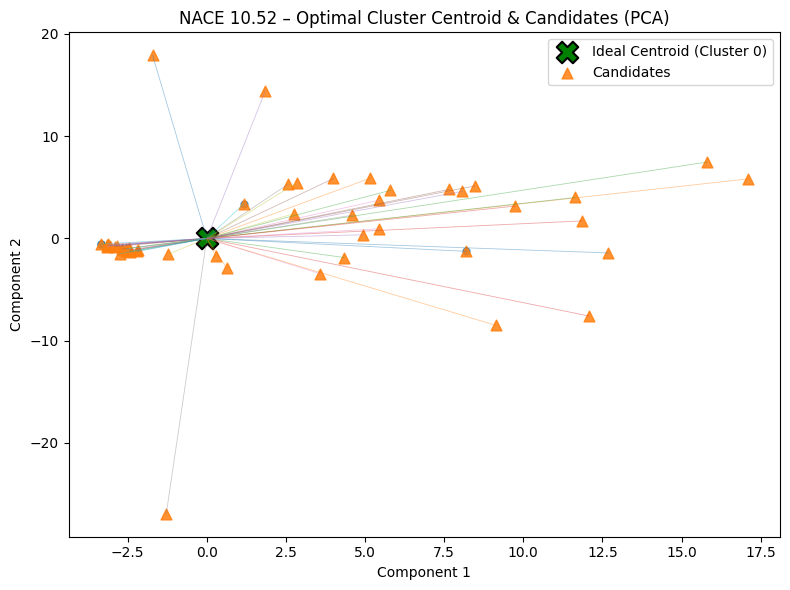

In [52]:
top_n = find_top_n_for_nace_code( 
    10.52,
    df_business_ELSTAT_neighborhood, 
    neighborhood_ELSTAT_df, 
    feature_columns, 
    top_n=10, 
    optimal_K=True, 
    judge_feature='unemployment_rate', 
    approach_name='2. Approach 2',
    plot=False,
    extra_visuals=True,
    method="pca"
)